In [ ]:
!pip install medmnist

In [ ]:
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms

import medmnist
from medmnist import INFO, Evaluator

In [ ]:
download = True

NUM_EPOCHS = 20
BATCH_SIZE = 128
lr = 0.001

info = INFO['bloodmnist']
task = 'multi-class'
n_channels = 3
n_classes = 8

DataClass = getattr(medmnist, info['python_class'])


In [ ]:
# preprocessing
data_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

# load the data
train_dataset = DataClass(split='train', transform=data_transform, download=download)
test_dataset = DataClass(split='test', transform=data_transform, download=download)

pil_dataset = DataClass(split='train', download=download)

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
train_loader_at_eval = data.DataLoader(dataset=train_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=2*BATCH_SIZE, shuffle=False)

In [ ]:
print(train_dataset)
print("===================")
print(test_dataset)

Dataset BloodMNIST of size 28 (bloodmnist)
    Number of datapoints: 11959
    Root location: /root/.medmnist
    Split: train
    Task: multi-class
    Number of channels: 3
    Meaning of labels: {'0': 'basophil', '1': 'eosinophil', '2': 'erythroblast', '3': 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', '4': 'lymphocyte', '5': 'monocyte', '6': 'neutrophil', '7': 'platelet'}
    Number of samples: {'train': 11959, 'val': 1712, 'test': 3421}
    Description: The BloodMNIST is based on a dataset of individual normal cells, captured from individuals without infection, hematologic or oncologic disease and free of any pharmacologic treatment at the moment of blood collection. It contains a total of 17,092 images and is organized into 8 classes. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images with resolution 3×360×363 pixels are center-cropped into 3×200×200, and then resized into 3×28×28.
    License: CC B

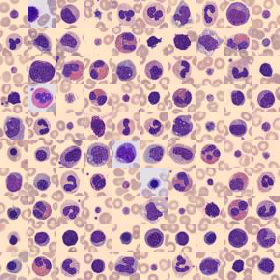

In [ ]:
# visualization
train_dataset.montage(length=10)

In [ ]:
# define a simple CNN model

class Net(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(Net, self).__init__()

        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3),
            nn.BatchNorm2d(16),
            nn.ReLU())

        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 16, kernel_size=3),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))

        self.layer3 = nn.Sequential(
            nn.Conv2d(16, 64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU())

        self.layer4 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU())

        self.layer5 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))

        self.fc = nn.Sequential(
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes))

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = Net(in_channels=n_channels, num_classes=n_classes)

# define loss function and optimizer
if task == "multi-label, binary-class":
    criterion = nn.BCEWithLogitsLoss()
else:
    criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

In [ ]:
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

for epoch in range(NUM_EPOCHS):
    # train
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for inputs, targets in tqdm(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)

        targets = targets.squeeze().long()
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        train_total += targets.size(0)
        train_correct += predicted.eq(targets).sum().item()

    # validate
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        # Use the internal MedMNIST validation split
        val_dataset = DataClass(split='val', transform=data_transform, download=download)
        val_loader = data.DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)

        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)

            targets = targets.squeeze().long()
            loss = criterion(outputs, targets)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += targets.size(0)
            val_correct += predicted.eq(targets).sum().item()

    # Save metrics
    history['train_loss'].append(train_loss / len(train_loader))
    history['train_acc'].append(100. * train_correct / train_total)
    history['val_loss'].append(val_loss / len(val_loader))
    history['val_acc'].append(100. * val_correct / val_total)

    print(f'Epoch {epoch+1}: Train Acc: {history["train_acc"][-1]:.2f}% | Val Acc: {history["val_acc"][-1]:.2f}%')

100%|██████████| 94/94 [00:25<00:00,  3.68it/s]


Epoch 1: Train Acc: 35.68% | Val Acc: 56.72%


100%|██████████| 94/94 [00:25<00:00,  3.73it/s]


Epoch 2: Train Acc: 68.79% | Val Acc: 74.36%


100%|██████████| 94/94 [00:25<00:00,  3.74it/s]


...

Epoch 18: Train Acc: 93.03% | Val Acc: 92.29%


100%|██████████| 94/94 [00:25<00:00,  3.71it/s]


Epoch 19: Train Acc: 92.85% | Val Acc: 90.19%


100%|██████████| 94/94 [00:25<00:00,  3.72it/s]


Epoch 20: Train Acc: 93.44% | Val Acc: 94.22%


In [ ]:
# evaluation

def test(split):
    model.eval()
    y_true = torch.tensor([])
    y_score = torch.tensor([])

    data_loader = train_loader_at_eval if split == 'train' else test_loader

    with torch.no_grad():
        for inputs, targets in data_loader:
            outputs = model(inputs)

            if task == 'multi-label, binary-class':
                targets = targets.to(torch.float32)
                outputs = outputs.softmax(dim=-1)
            else:
                targets = targets.squeeze().long()
                outputs = outputs.softmax(dim=-1)
                targets = targets.float().resize_(len(targets), 1)

            y_true = torch.cat((y_true, targets), 0)
            y_score = torch.cat((y_score, outputs), 0)

        y_true = y_true.numpy()
        y_score = y_score.detach().numpy()

        evaluator = Evaluator('bloodmnist', split)
        metrics = evaluator.evaluate(y_score)

        print('%s  auc: %.3f  acc:%.3f' % (split, *metrics))

test('train')
test('test')

train  auc: 0.996  acc:0.934
test  auc: 0.995  acc:0.924


# Visualizations

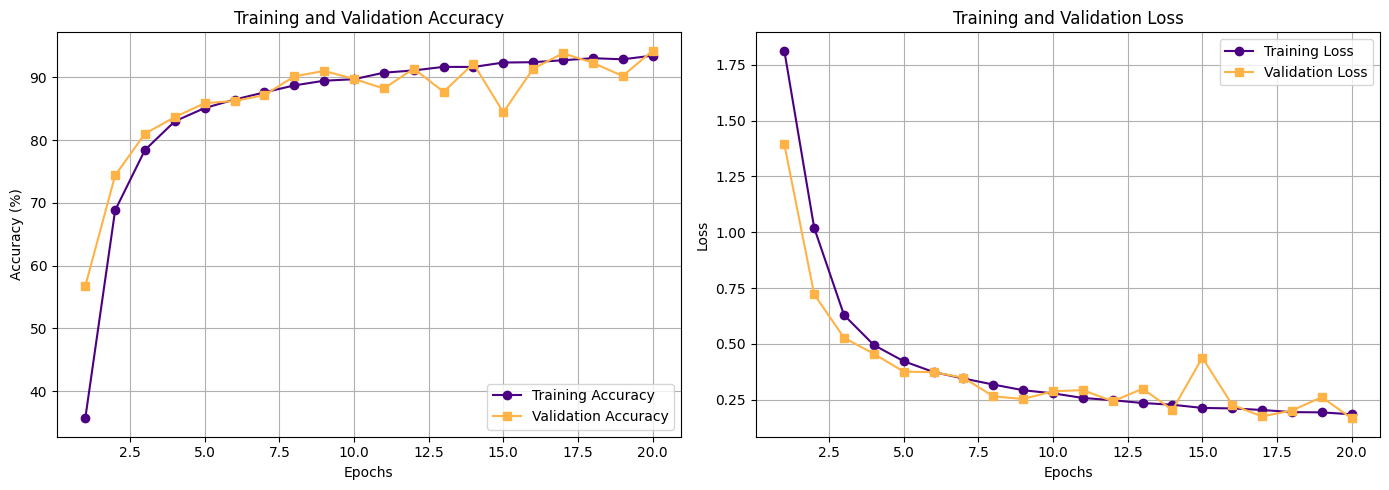

In [ ]:
import matplotlib.pyplot as plt

# Define your epochs range based on your training
epochs_range = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(14, 5))

# Plot Accuracy: Training vs Validation
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_acc'],
         label='Training Accuracy', marker='o',
         color='indigo') # Dark Purple
plt.plot(epochs_range, history['val_acc'],
         label='Validation Accuracy', marker='s',
         color='#FFB347') # Mild Yellow-Orange
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(loc='lower right')
plt.grid(True)

# Plot Loss: Training vs Validation
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_loss'],
         label='Training Loss', marker='o',
         color='indigo') # Dark Purple
plt.plot(epochs_range, history['val_loss'],
         label='Validation Loss', marker='s',
         color='#FFB347') # Mild Yellow-Orange
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

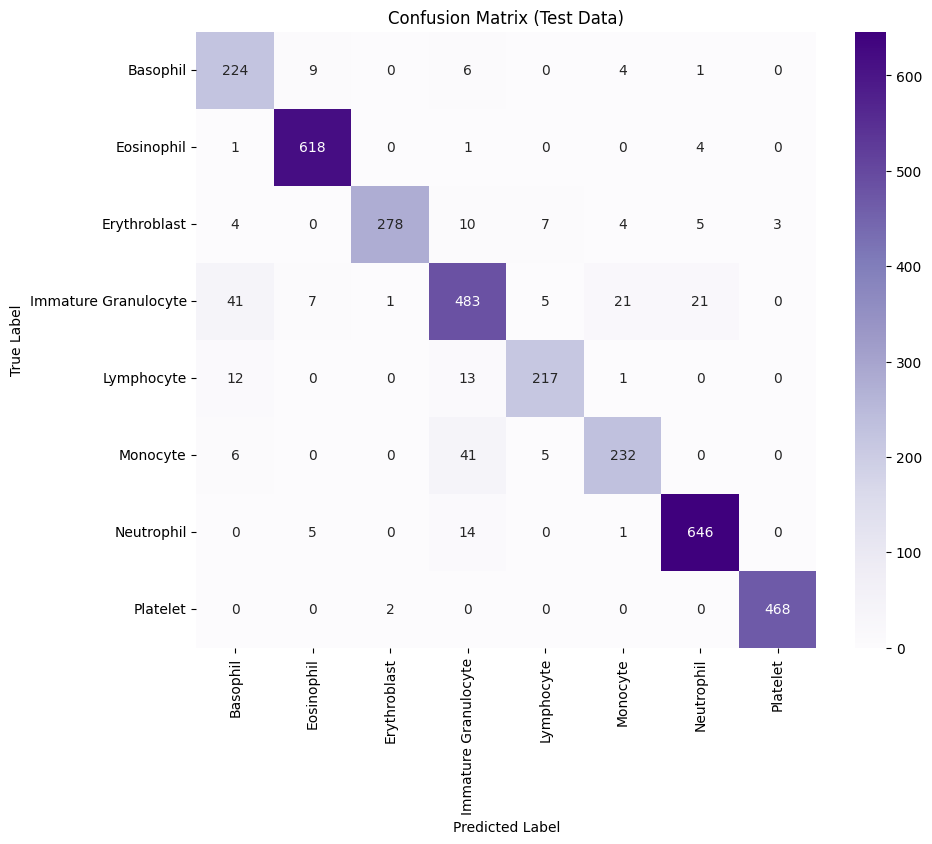

In [ ]:

class_names = [
    "Basophil",
    "Eosinophil",
    "Erythroblast",
    "Immature Granulocyte", # Abbreviation for Immature Granulocytes
    "Lymphocyte",
    "Monocyte",
    "Neutrophil",
    "Platelet"
]

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix (Test Data)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

/tmp/ipykernel_162/649327099.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label_idx = int(label)


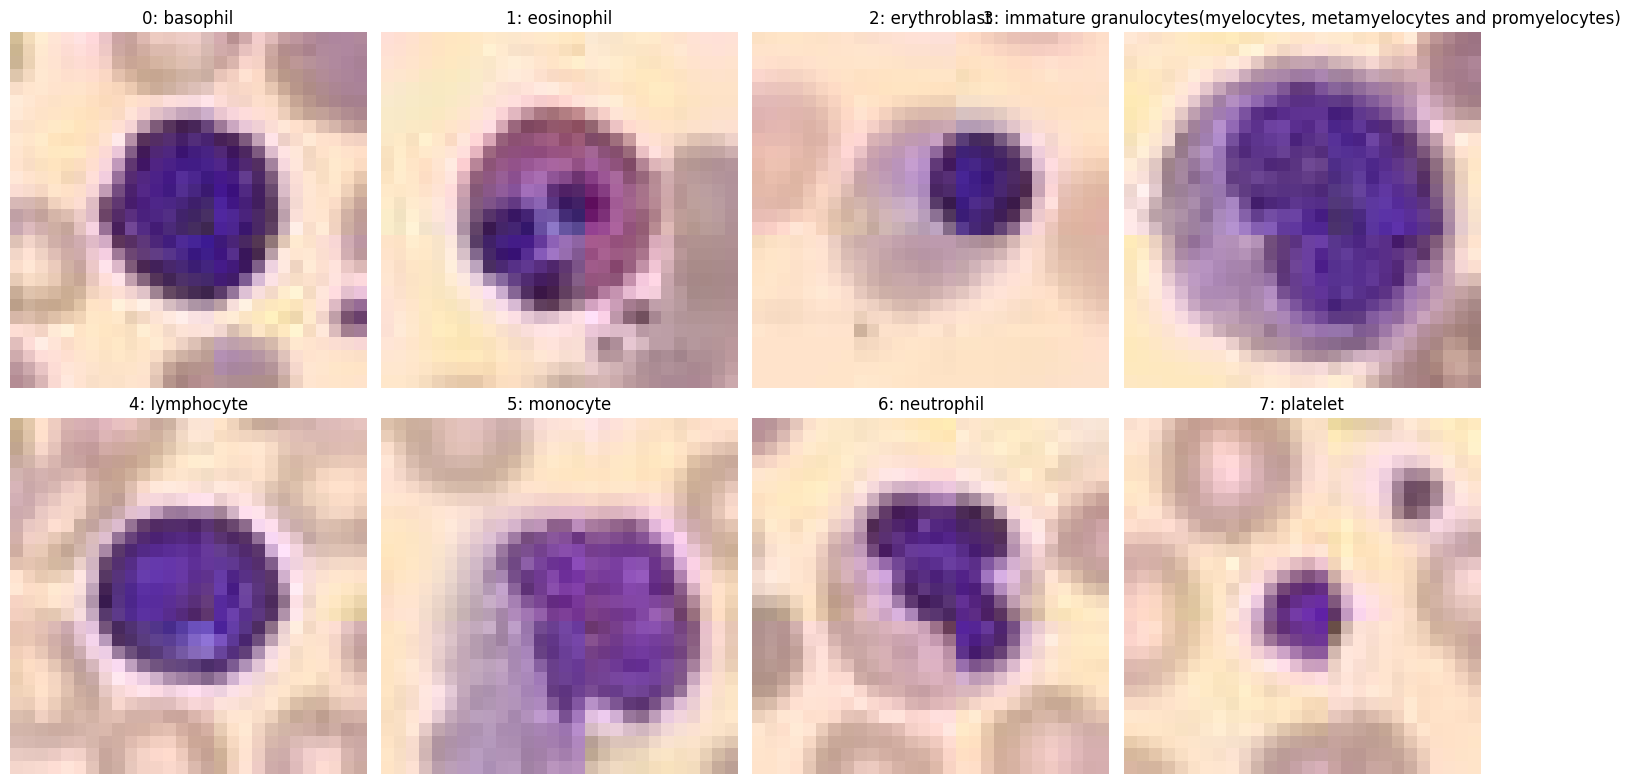

In [ ]:
import matplotlib.pyplot as plt

# 1. Create a dictionary to store one example for each class
# Class names are: 0: basophil, 1: eosinophil, 2: erythroblast, 3: immature granulocyte,
# 4: lymphocyte, 5: monocyte, 6: neutrophil, 7: platelet
found_classes = {}
class_names = info['label']

# 2. Iterate through the dataset until we find an example of each
for img, label in pil_dataset:
    label_idx = int(label)
    if label_idx not in found_classes:
        found_classes[label_idx] = img
    if len(found_classes) == 8: # Stop once we have all 8
        break

# 3. Plot the images in a grid
plt.figure(figsize=(15, 8))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(found_classes[i])
    plt.title(f"{i}: {class_names[str(i)]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

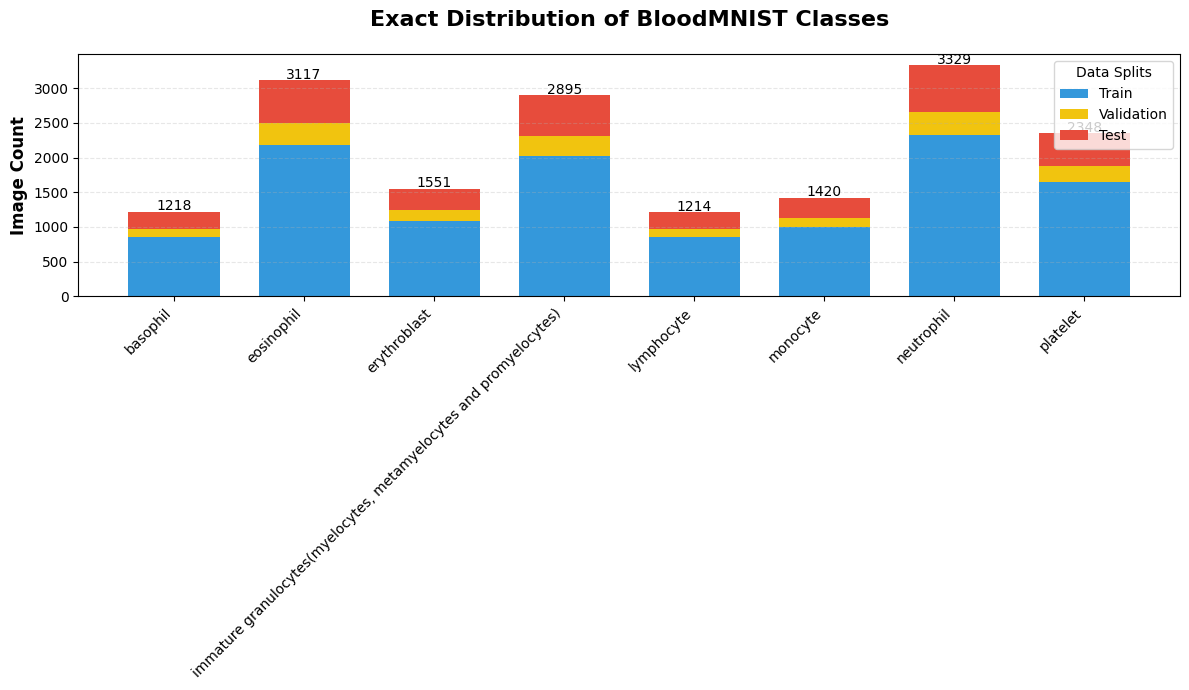

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from medmnist import BloodMNIST

# 1. Load all splits to get actual counts
splits = ['train', 'val', 'test']
class_labels = BloodMNIST(split='train').info['label']
class_names = [class_labels[str(i)] for i in range(8)]

data_counts = {split: np.zeros(8) for split in splits}

for split in splits:
    dataset = BloodMNIST(split=split)
    # dataset.labels is an array of shape (N, 1)
    labels = dataset.labels.flatten()
    for i in range(8):
        data_counts[split][i] = np.sum(labels == i)

# 2. Plotting
fig, ax = plt.subplots(figsize=(12, 7))
width = 0.7

# Stacked bars: Train (bottom), Val (middle), Test (top)
ax.bar(class_names, data_counts['train'], width, label='Train', color='#3498db')
ax.bar(class_names, data_counts['val'], width, bottom=data_counts['train'], label='Validation', color='#f1c40f')
ax.bar(class_names, data_counts['test'], width, bottom=data_counts['train'] + data_counts['val'], label='Test', color='#e74c3c')

# 3. Aesthetics
ax.set_ylabel('Image Count', fontsize=12, fontweight='bold')
ax.set_title('Exact Distribution of BloodMNIST Classes', fontsize=16, fontweight='bold', pad=20)
ax.legend(title="Data Splits", loc='upper right')
plt.xticks(rotation=45, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.3)

# Add exact total labels on top
totals = data_counts['train'] + data_counts['val'] + data_counts['test']
for i, total in enumerate(totals):
    ax.text(i, total + 20, int(total), ha='center', color='black')

plt.tight_layout()
plt.show()